In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\hamed\.cache\kagglehub\datasets\subhaditya\fer2013plus\versions\1


In [9]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define data transformations
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)) 
    ]),
    "test": transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
}

# Paths to dataset
train_dir = path + "/fer2013plus/fer2013/train" 
test_dir = path + "/fer2013plus/fer2013/test" 

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms["train"])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms["test"])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train loader and test loader created!")


# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)


# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Train loader and test loader created!
Image batch shape: torch.Size([32, 3, 48, 48])
Labels batch shape: torch.Size([32])
Labels: tensor([4, 5, 6, 5, 4, 5, 5, 0, 7, 5, 5, 6, 0, 7, 4, 5, 7, 6, 4, 5, 5, 3, 7, 7,
        5, 4, 7, 5, 4, 4, 4, 4])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


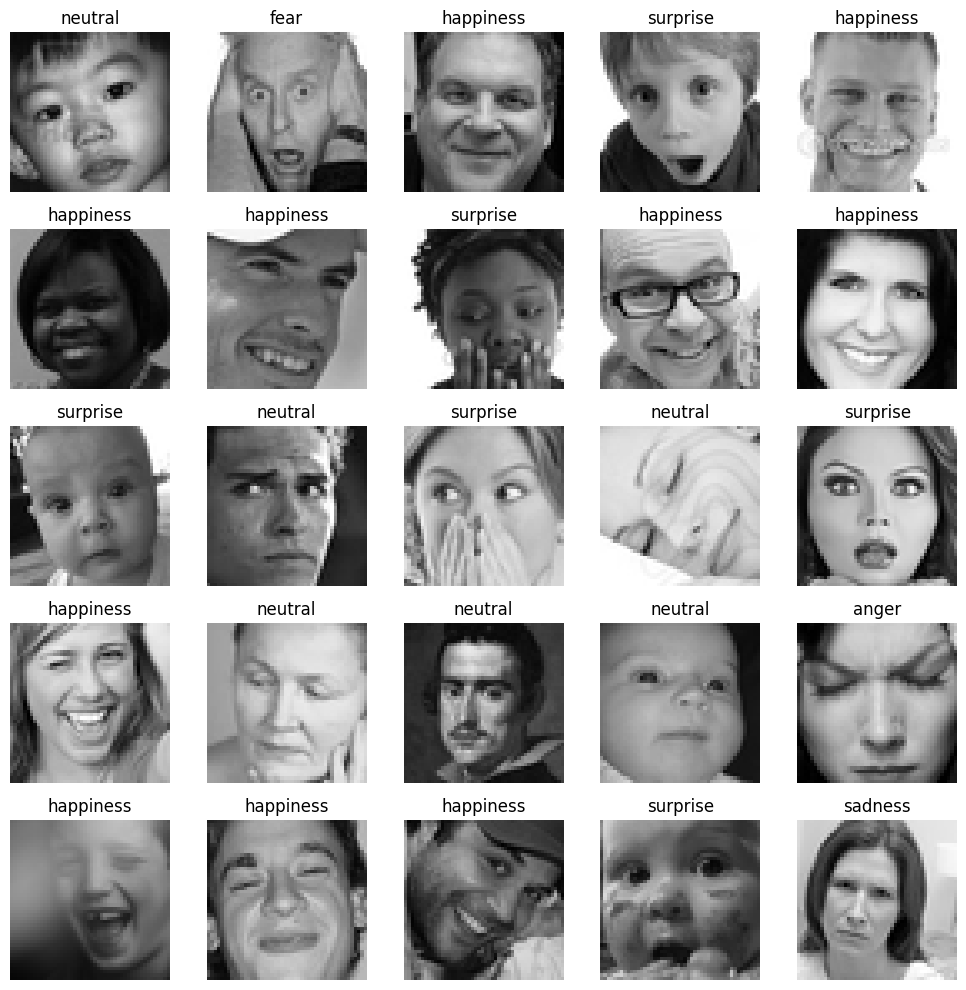

In [7]:
import matplotlib.pyplot as plt

def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy() 


    images = images * 0.5 + 0.5  


    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5) 
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_image_batch(images, labels, class_names)


In [8]:
import torch.nn.functional as F
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)  # Grayscale
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(in_features=64 * 12 * 12, out_features=128)  # Adjusted for 48x48 input
        self.fc2 = nn.Linear(in_features=128, out_features=8)  # 8 emotion classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Activation after conv1 + pooling
        x = self.pool(F.relu(self.conv2(x)))  # Activation after conv2 + pooling
        x = x.view(-1, 64 * 12 * 12)  # Flatten tensor for fully connected layers
        x = F.relu(self.fc1(x))  # Fully connected layer 1 with activation
        x = self.fc2(x)  # Output layer
        return x


model = CNN()


In [ ]:
import torch.optim as optim

# Step 4: Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.SGD(model.parameters(), lr=0.001)  # call optimizer

In [ ]:
# Step 5: Train the Model
num_epochs = 2  # define number of epochs
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i + 1) % 100 == 0:  # Print every 100 batches
            print(
                f"Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}")
            running_loss = 0.0